<center>

# M586 Project Proposal
## Analyzing the ENSO pattern via Finite Differences and SVD

### Matthew T., Arthur P., Ilcia P., Richard P.

---

## Proposal

#### (i)
##### This project proposes a data-driven oceanic study of ENSO-related events using monthly GODAS ocean data from NOAA over the 1980–2019 period. For the analysis, our group will focus on potential temperature fields and build a structured pipeline aimed at dimensionality reduction. Rather than examining the full global grid, our study will narrows the spatial subset to just the tropical Pacific at the 5 meter depth. We decided to choose this region as we figured they would be most relevant to large-scale ENSO behavior. It also makes the analysis both computationally manageable and physically targeted.

#### (ii)
##### The first stage of the project constructs monthly climatologies and anomaly fields from the GODAS data. We learned the concept of climatologies in the early chapters of Math 586, where long-term monthly means are subtracted to produce a matrix of anomalies that emphasizes departures from normal conditions. This is important because ENSO is not simply a warm or cool snapshot, but rather a pattern of variability relative to expected oceanic conditions. By flattening each 3D monthly field into a vector, we can organize the anomalies into matrices that allow for consistent comparison across years, months, and spatial locations.

##### The main methodological idea of this project is to treat the anomaly field, composed of appended flattened arrays, as a function of both year and month. In doing so, we can apply concepts learned in courses such as Math 342 by using finite difference schemes in each direction to capture changes in temporal structure. We implement a modified centered difference scheme that is second-order accurate. First, we estimate a seasonal derivative across the months of each year by incorporating nearby months (October, November, January, and February) to approximate the derivative over the boreal winter window (November, December, January). We then apply a second round of the centered difference scheme across all years. With this methodology, we aim to produce a mixed temporal derivative that illustrates how the rate of change during each boreal winter shifts from year to year. This serves as the core contribution of the proposal: **instead of analyzing the anomaly field directly, we study a derivative-based field that may better highlight transitions, intensifications, and evolving seasonal structure.**

##### After constructing this mixed-derivative field, we form a large matrix and apply Singular Value Decomposition (SVD) to extract the most dominant spatial modes and their associated behaviors. This allows us, as data scientists, to identify leading patterns related to the year-to-year evolution of wintertime anomalies. In practical terms, the SVD step provides empirical orthogonal functions (EOFs) and principal component (PC) time series that can be analyzed for major oceanic variability patterns within the tropical Pacific. Because the analysis is performed after the finite-difference transformation, the resulting modes are intended to represent not only variability, but variability in the changing pace and direction of seasonal evolution.

#### (iii)
##### Overall, this project uses known mathematical methods in a more nuanced approach, framed as an effort to build a new perspective on ENSO analysis by combining data ETL, discrete differential methods, and mathematical dimensionality reduction. Its value lies in moving beyond static monthly averages toward a representation that captures how ocean conditions evolve across both seasons and years. The expected outcome is a set of interpretable dominant modes that could reveal transitional behaviors and seasonal evolution patterns in the tropical Pacific more sharply than traditional anomaly-based approaches. As a proposal, we aim to ensure this project scientifically meaningful, computationally achievable, and grounded in a clear mathematical workflow that can be extended to other seasonal phenomena.

---


![First 3 Modes Principal Components](F3M_NOV+OCT-JAN+FEB.png) 

![First 4 Modes Spatial EOFs](F3M_Raw_December_Anomalies.png) 

---

## Methodology

---

#### The datasets we will use is National Centers for Environmental Predictions (NCEP) Global Ocean Data Assimilation System (GODAS) data across 40 years from 1980 to 2020. Sourced from the National Oceanic and Atmospheric Administration (NOAA)

---

### Data Download


In [ ]:
from pathlib import Path
from NOAA_data_download import _make_session, download_godas
godas_folder = Path("GODAS_data")
session     = _make_session()
download_godas(godas_folder, 2025, session)

---

### Matrix Dimensions for GODAS Monthly-Mean Files

<div style="margin:0 0 0 25px;">

Given one yearly GODAS file with dimensions

$$
(\text{level}, \text{lon}, \text{lat}, \text{time}) = (40, 360, 418, 12),
$$

each file contains $12$ monthly mean fields, and each monthly field is a $3$-dimensional tensor of size

$$
40 \times 360 \times 418 = 6{,}019{,}200 \text{ Raw data points}.
$$

</div>

In [ ]:
import numpy as np
import xarray as xr
import os

FOLDERPATH  = r"D:\\OneDrive\\Documents\\M586_Project\\GODAS_data"
VARIABLE    = "pottmp"
YEARS       = list(range(1980, 2020))          # 1980–2019  (40 years)
OUTPUT_PATH = r"D:\\OneDrive\\Documents\\M586_Project\\GODAS_Partials_SVD_results_NDJ.nc"

LON_MIN, LON_MAX  = 100, 300
LAT_MIN, LAT_MAX  = -40, 40
DEPTH_IDX_MAX     = 30                         # levels 0–29

N_LON   = LON_MAX - LON_MIN                   # 200
N_LAT   = (abs(LAT_MAX) + abs(LAT_MIN)) * 3   # grid points in [-40, 40] = 240 Since 0.5 resolution => 80 per 40 degrees => 160 for 80 degrees
N_LEV   = DEPTH_IDX_MAX                       # 30
N       = N_LEV * N_LON * N_LAT               # 1440000
N_YEARS = len(YEARS)                          # 40
N_MON   = 12

print(f"Spatial dimension  N = {N:,}")
print(f"Years : {YEARS[0]}–{YEARS[-1]}  ({N_YEARS} years)")


Spatial dimension  N = 1,440,000
Years : 1980–2019  (40 years)


---

### 1. Full-Grid Dimensions of One Monthly Field

<div style="margin:0 0 0 25px;">

For a **fixed year $y$** and **month $m$**, the raw monthly mean field loaded from the GODAS file is

$$
X_{y,m}^{\text{full}} \in \mathbb{R}^{40 \times 360 \times 418},
$$

with axes ordered as (level, longitude, latitude). Before any flattening or further computation, we restrict this field to a physically motivated subdomain, as described in Section 2.

</div>

In [2]:
# ── 1. Full-Grid Dimensions — verification ────────────────────────────────────
fpath  = f"{FOLDERPATH}\\{VARIABLE}.{YEARS[0]}.nc"
ds_tmp = xr.open_dataset(fpath);
print("Full-grid shape (level, lon, lat, time):", ds_tmp[VARIABLE].shape)
ds_tmp.close()


C:\Users\Matt\AppData\Roaming\Python\Python311\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'cfgrib' loading failed:
module 'cfgrib.messages' has no attribute 'DEFAULT_INDEXPATH'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
c:\Users\Matt\anaconda3\Lib\site-packages\cupy\_environment.py:217: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


Full-grid shape (level, lon, lat, time): (12, 40, 418, 360)


---

### 2. Spatial Subsetting

<div style="margin:0 0 0 25px;">

Working with the full $40 \times 360 \times 418 = 6{,}019{,}200$ grid is computationally expensive and includes large regions irrelevant to tropical Pacific variability. We therefore restrict each monthly field to a subdomain defined by the following index ranges:

| Dimension | Full size | Subset range | Subset index size |
|-----------|-----------|--------------|-------------|
| Longitude | 360 points $(0^\circ\text{E}\text{ to }359^\circ\text{E})$ | $100^\circ\text{E}$ to $300^\circ\text{E}$ | 200 |
| Latitude | 418 points | $-40^\circ$ S to $40^\circ$ N | 240 |
| Depth (level index) | 40 levels | Indices $0$–$29$ | 30 |

The 30 retained depth levels correspond to the following nominal depths in meters:

$$
z \in \{5, 15, 25, 35, 45, 55, 65, 75, 85, 95, 105, 115, 125, 135, 145,
$$
$$
155, 165, 175, 185, 195, 205, 215, 225, 238, 262, 303, 366, 459, 584, 747\}\ \text{m}.
$$

The subsetting selects the upper ocean down to $747$ m, spanning the thermocline and capturing the bulk of ENSO-relevant heat content variability. The longitude window $[100^\circ\text{E},\ 300^\circ\text{E}]$ covers the Indo-Pacific basin, and the latitude band $[-40^\circ,\ 40^\circ]$ focuses on the deep tropics and subtropics where ENSO forcing and response are concentrated.

Denote the subsetted field as

$$
X_{y,m} = X_{y,m}^{\text{full}}\big[0{:}30,\ 100{:}300,\ {\cdot}\big] \in \mathbb{R}^{30 \times 200 \times 240},
$$

where the latitude axis has already been filtered to the $[-40^\circ, 40^\circ]$ band of 240 grid points. All subsequent operations are performed on $X_{y,m}$, not the full-grid field.

After flattening the subsetted spatial dimensions into a single vector, we obtain

$$
x_{y,m} = \operatorname{vec}(X_{y,m}) \in \mathbb{R}^N,
$$

where the subsetted spatial dimension is

$$
N = 30 \times 200 \times 240 = 1{,}440{,}000.
$$

This reduces the per-field vector length by a factor of

$$
\frac{6{,}019{,}200}{1{,}440{,}000} \approx 4.18,
$$

a substantial reduction in memory and compute for all downstream operations.

</div>

In [3]:
# ── 2. Spatial Subsetting ────────────────────────────────────────────────────
# Load every year–month field, subset, flatten.
# X_all[y, m, :] = vec(X_{y,m})   shape determined from the actual subset

sample_path = f"{FOLDERPATH}\\{VARIABLE}.{YEARS[0]}.nc"
with xr.open_dataset(sample_path) as ds_sample:
    sample_sub = (ds_sample[VARIABLE]
                  .isel(level=slice(0, DEPTH_IDX_MAX))
                  .sel(lon=slice(LON_MIN, LON_MAX),
                       lat=slice(LAT_MIN, LAT_MAX))
                  .transpose("time", "level", "lon", "lat"))

N_LEV = sample_sub.sizes["level"]
N_LON = sample_sub.sizes["lon"]
N_LAT = sample_sub.sizes["lat"]
N = N_LEV * N_LON * N_LAT

X_all = np.empty((N_YEARS, N_MON, N), dtype=np.float32)

for yi, year in enumerate(YEARS):
    fpath = f"{FOLDERPATH}\\{VARIABLE}.{year}.nc"
    with xr.open_dataset(fpath) as ds:
        sub = (ds[VARIABLE]
               .isel(level=slice(0, DEPTH_IDX_MAX))
               .sel(lon=slice(LON_MIN, LON_MAX),
                    lat=slice(LAT_MIN, LAT_MAX))
               .transpose("time", "level", "lon", "lat"))
        X_all[yi, :, :] = sub.values.reshape(N_MON, N)

print(f"Subset sizes -> level: {N_LEV}, lon: {N_LON}, lat: {N_LAT}, N: {N:,}")
print(f"X_all shape: {X_all.shape}")


Subset sizes -> level: 30, lon: 200, lat: 240, N: 1,440,000
X_all shape: (40, 12, 1440000)


---

### 3. Data Size for One Fixed Month Across $40$ Years

<div style="margin:0 0 0 25px;">

Fix one calendar month $m$. Across $Y = 40$ years, we collect the sequence

$$
x_{1,m},\ x_{2,m},\ \dots,\ x_{40,m}, \qquad x_{y,m} \in \mathbb{R}^{1{,}440{,}000}.
$$

Arranging these as columns gives the raw month-specific data matrix

$$
A_m =
\begin{bmatrix}
| & | & & | \\
x_{1,m} & x_{2,m} & \cdots & x_{40,m} \\
| & | & & |
\end{bmatrix}
\in \mathbb{R}^{1{,}440{,}000 \times 40}.
$$

The total number of scalar entries is

$$
1{,}440{,}000 \times 40 = 57{,}600{,}000.
$$

</div>

In [4]:
# ── 3. Data Size for One Fixed Month Across 40 Years ─────────────────────────
# A_m = X_all[:, m, :].T  has shape (N, 40) for any fixed m

m_check = 0   # January (0-indexed)
A_m = X_all[:, m_check, :].T
print(f"A_m (month={m_check + 1}) shape : {A_m.shape}")   # (1440000, 40)
print(f"Total scalar entries   : {A_m.size:,}")           # 57,600,000
del A_m


A_m (month=1) shape : (1440000, 40)
Total scalar entries   : 57,600,000


---

### 4. Monthly Climatology for a Fixed Month

<div style="margin:0 0 0 25px;">

For each fixed month $m$, the climatological mean field is

$$
\overline{x}_m = \frac{1}{40}\sum_{y=1}^{40} x_{y,m} \in \mathbb{R}^{1{,}440{,}000}.
$$

This gives one climatological vector per calendar month.

</div>

In [5]:
# ── 4. Monthly Climatology for a Fixed Month ──────────────────────────────────
# x_bar[m, :] = (1/40) * sum_y X_all[y, m, :]
# shape: (12, 1440000)

x_bar = X_all.mean(axis=0)
print(f"x_bar shape: {x_bar.shape}")   # (12, 1440000)


x_bar shape: (12, 1440000)


---

### 5. Anomaly Vectors

<div style="margin:0 0 0 25px;">

For each year $y$ and month $m$, define the anomaly vector

$$
a_{y,m} = x_{y,m} - \overline{x}_m \in \mathbb{R}^{1{,}440{,}000}.
$$

Arranging these as columns gives the anomaly matrix for month $m$:

$$
\widetilde{A}_m =
\begin{bmatrix}
| & | & & | \\
a_{1,m} & a_{2,m} & \cdots & a_{40,m} \\
| & | & & |
\end{bmatrix}
\in \mathbb{R}^{1{,}440{,}000 \times 40}.
$$

</div>

In [ ]:
# ── 5. Anomaly Vectors ────────────────────────────────────────────────────────
# a[y, m, :] = X_all[y, m, :] - x_bar[m, :]
# shape: (40, 12, 1440000)

A_anom = X_all - x_bar[np.newaxis, :, :]
print(f"A_anom shape: {A_anom.shape}")   # (40, 12, 1440000)

del X_all   # raw data no longer needed


A_anom shape: (40, 12, 1440000)


In [7]:
# ── 5b. Extract December Anomalies for Interior Years ─────────────────────
# Must be captured here, before A_anom is deleted in the derivative cell below.
# Interior years 1981–2018 (indices 1..38) match the derivative SVD year range.
# Shape: (38, N)

dec_anom_interior = A_anom[1:-1, 11, :].copy()
print(f"dec_anom_interior shape: {dec_anom_interior.shape}")   # (38, N)

dec_anom_interior shape: (38, 1440000)


---

## Mixed Partial Derivative Plan

<div style="margin:0 0 0 25px;">

We treat the anomaly field $a_{y,m} \in \mathbb{R}^N$ as a function of two discrete variables,

$$
a = a(y, m), \qquad y = 1,\dots,40, \quad m = 1,\dots,12,
$$

and apply two successive centered finite differences before constructing the SVD input matrix.

</div>

---

### 6. First Derivative: 4th-Order Centered Difference Over the DJF Window

<div style="margin:0 0 0 25px;">

Rather than applying a 2-point centered difference across all 12 months, we restrict attention to the boreal winter season and use a higher-order stencil. The goal is to estimate the local rate of change of the anomaly field through December, using October, November, January, and February as the surrounding support points.

The standard 4th-order centered finite difference approximates $\partial a / \partial m$ at the center point $m = \text{Dec}$ as

$$
\delta_m^{(4)} a_{y,\text{Dec}}
= \frac{-a_{y,\text{Oct}} + 8\,a_{y,\text{Nov}} - 8\,a_{y,\text{Jan}} + a_{y,\text{Feb}}}{12},
$$

where the denominator $12 = 12\,\Delta m$ follows from the 4th-order weight formula with $\Delta m = 1$ month. Note that December itself does not appear in the numerator — it is the implicit center point whose derivative is being approximated, and the stencil coefficients $(-1, +8, 0, -8, +1)$ cancel it exactly.

This produces one spatial vector per year,

$$
\delta_m^{(4)} a_{y,\text{Dec}} \in \mathbb{R}^N, \qquad y = 1,\dots,40,
$$

capturing the local seasonal rate of change of the anomaly field through the DJF window.

</div>

In [8]:
# ── 6. First Derivative: 4th-order centered difference over DJF window ───────
# Uses Oct, Nov, Jan, Feb as the 5-point stencil centered on December
# Indices: Oct=9, Nov=10, Dec=11, Jan=0, Feb=1
# Formula: (-a_Oct + 8*a_Nov - 8*a_Jan + a_Feb) / 12
# Produces one spatial vector per year: shape (40, N)

delta_DJF = (
    - A_anom[:, 9,  :]       # October
    + 8 * A_anom[:, 10, :]   # November
    - 8 * A_anom[:, 0,  :]   # January
    +     A_anom[:, 1,  :]   # February
) / 12.0

print(f"delta_DJF shape: {delta_DJF.shape}")   # (40, N)
del A_anom

delta_DJF shape: (40, 1440000)


---

### 7. Second Derivative: Centered Difference Across Years

<div style="margin:0 0 0 25px;">

We now apply a centered difference in the year direction to the DJF seasonal derivative field. For each interior year $y \in \{2,\dots,39\}$,

$$
b_y = \frac{\delta_m^{(4)} a_{y+1,\text{Dec}} - \delta_m^{(4)} a_{y-1,\text{Dec}}}{2} \in \mathbb{R}^N.
$$

This approximates

$$
\frac{\partial}{\partial y}\left(\frac{\partial a}{\partial m}\right)(y,\,\text{Dec})
= \frac{\partial^2 a}{\partial y\,\partial m}\bigg|_{m=\text{Dec}},
$$

the mixed partial derivative of the anomaly field evaluated at the December center of the DJF window. Substituting the 4th-order stencil and expanding gives the closed-form expression

$$
\boxed{
b_y = \frac{
-a_{y+1,\text{Oct}} + 8\,a_{y+1,\text{Nov}} - 8\,a_{y+1,\text{Jan}} + a_{y+1,\text{Feb}}
-\bigl(-a_{y-1,\text{Oct}} + 8\,a_{y-1,\text{Nov}} - 8\,a_{y-1,\text{Jan}} + a_{y-1,\text{Feb}}\bigr)
}{24}.
}
$$

The valid interior years are $y \in \{2,\dots,39\}$, yielding $38$ column vectors.

</div>

In [9]:
# ── 7. Second Derivative: Centered Difference Across Years ───────────────────
# b[y, :] = (delta_DJF[y+1, :] - delta_DJF[y-1, :]) / 2
# Valid interior years: y-index 1..38  ->  calendar years 1981-2018
# shape: (38, N)

b = (delta_DJF[2:, :] - delta_DJF[:-2, :]) / 2.0
print(f"b shape: {b.shape}")   # (38, N)
del delta_DJF

b shape: (38, 1440000)


---

### 8. Physical Interpretation

<div style="margin:0 0 0 25px;">

The quantity $b_y$ does not measure the anomaly itself, nor a simple month-to-month or year-to-year change. It measures

> how the rate of change of the anomaly field through the DJF seasonal window is itself shifting from year to year.

More precisely:

- $\delta_m^{(4)} a_{y,\text{Dec}}$ asks: how fast is the anomaly field evolving through boreal winter in year $y$?
- $b_y$ asks: how is that wintertime rate of change itself evolving across decades?

Restricting the month derivative to the DJF window before taking the year derivative focuses the analysis on the season of peak ENSO expression. The 4th-order stencil improves on the 2-point scheme by using five months of support, reducing truncation error and weighting the immediately adjacent months (November, January) eight times more heavily than the outer months (October, February).

</div>

In [10]:
# ── 8. Physical Interpretation -- shape sanity check ─────────────────────────
print(f"Interior years covered : {YEARS[1]}-{YEARS[-2]}")
print(f"Number of columns in B : {b.shape[0]}")   # 38


Interior years covered : 1981-2018
Number of columns in B : 38


---

### 9. Constructing the SVD Input Matrix

<div style="margin:0 0 0 25px;">

Define the mixed-derivative field at each interior year as

$$
b_y \in \mathbb{R}^N, \qquad N = 1{,}440{,}000, \quad y \in \{2,\dots,39\}.
$$

Arranging these as columns produces the SVD input matrix

$$
B =
\begin{bmatrix}
| & | & & | \\
b_2 & b_3 & \cdots & b_{39} \\
| & | & & |
\end{bmatrix}
\in \mathbb{R}^{1{,}440{,}000 \times 38}.
$$

Because $N = 1{,}440{,}000 \gg 38$, operating directly on $B$ is expensive. Instead we compute the SVD via the cross-product matrix $B^\top B \in \mathbb{R}^{38 \times 38}$, which is small enough for an exact dense eigendecomposition.

**Step 1 — Form the cross-product matrix.**

$$
C = B^\top B \in \mathbb{R}^{38 \times 38}.
$$

$C$ is symmetric positive semi-definite. Its eigenvalues are the squares of the singular values of $B$, and its eigenvectors are the right singular vectors of $B$.

**Step 2 — Eigendecompose $C$.**

$$
C = V \Lambda V^\top,
$$

where $\Lambda = \operatorname{diag}(\lambda_1, \dots, \lambda_{38})$ with $\lambda_1 \geq \lambda_2 \geq \cdots \geq 0$, and the columns of $V \in \mathbb{R}^{38 \times 38}$ are the corresponding orthonormal eigenvectors.

**Step 3 — Recover the singular values.**

$$
\sigma_i = \sqrt{\lambda_i}, \qquad i = 1, \dots, 38.
$$

**Step 4 — Recover the left singular vectors.**

For each $i$ with $\sigma_i > 0$, the $i$-th column of $U$ is

$$
u_i = \frac{1}{\sigma_i} B v_i \in \mathbb{R}^{1{,}440{,}000},
$$

where $v_i$ is the $i$-th column of $V$. In matrix form,

$$
U = B V \Sigma^{-1}, \qquad U \in \mathbb{R}^{1{,}440{,}000 \times 38}.
$$

This recovers the full thin SVD

$$
B = U \Sigma V^\top,
$$

where the columns of $U$ are the spatial weights (EOFs of the DJF mixed-derivative field), the diagonal entries of $\Sigma$ are the singular values in descending order, and the rows of $V^\top$ encode the temporal structure across the $38$ interior years $\{1981,\dots,2018\}$.

</div>

In [11]:
# ── 9. Constructing the SVD Input Matrix ─────────────────────────────────────
# B[:, col] = b[yi, :]   col = yi  (one per interior year)
# B shape: (N, 38)

B = b.T
print(f"B shape: {B.shape}")   # (N, 38)
del b

# -- Valid ocean mask ---------------------------------------------------------
valid_mask = ~np.any(np.isnan(B), axis=1)
n_valid    = valid_mask.sum()
print(f"Valid ocean points : {n_valid:,}  /  {N:,}  ({100 * n_valid / N:.1f}%)")

B_valid = B[valid_mask, :]
print(f"B_valid shape      : {B_valid.shape}")   # (n_valid, 38)
del B

# -- BtB cross-product SVD ----------------------------------------------------
print("Step 1 -- forming BtB (38x38) ...")
BtB = B_valid.T @ B_valid

print("Step 2 -- eigendecomposing BtB ...")
eigvals, V_raw = np.linalg.eigh(BtB)
idx     = np.arange(len(eigvals) - 1, -1, -1)
eigvals = eigvals[idx]
V_eofs  = V_raw[:, idx]
sigma   = np.sqrt(np.maximum(eigvals, 0.0))

print("Step 3 -- computing U = B_valid V Sigma^-1 ...")
tol          = sigma[0] * 1e-12
valid_sv     = sigma > tol
U_valid      = np.zeros((n_valid, V_eofs.shape[1]), dtype=np.float64)
U_valid[:, valid_sv] = ((B_valid @ V_eofs[:, valid_sv])
                        / sigma[np.newaxis, valid_sv])

U_eofs = np.full((N, V_eofs.shape[1]), np.nan, dtype=np.float32)
U_eofs[valid_mask, :] = U_valid.astype(np.float32)

print(f"U shape  : {U_eofs.shape}")
print(f"sigma shape  : {sigma.shape}")
print(f"V shape  : {V_eofs.shape}")
print(f"Variance explained by EOF 1 : {sigma[0]**2 / (sigma**2).sum():.2%}")

# -- Save ---------------------------------------------------------------------
ds_out = xr.Dataset(
    {
        "U": xr.DataArray(
            U_eofs,
            dims=["spatial", "component"],
            attrs={"long_name": "Left singular vectors (spatial EOFs)",
                   "note":      "NaN at land/bathymetry points"}
        ),
        "sigma": xr.DataArray(
            sigma.astype(np.float64),
            dims=["component"],
            attrs={"long_name": "Singular values"}
        ),
        "V": xr.DataArray(
            V_eofs.astype(np.float32),
            dims=["year_index", "component"],
            attrs={"long_name": "Right singular vectors (temporal scores)",
                   "note":      "year_index 0 = 1981, year_index 37 = 2018"}
        ),
        "valid_mask": xr.DataArray(
            valid_mask,
            dims=["spatial"],
            attrs={"long_name": "Boolean mask -- True = valid ocean point"}
        ),
    },
    attrs={
        "description": "SVD of DJF 4th-order mixed-partial-derivative matrix B",
        "variable":    VARIABLE,
        "years":       f"{YEARS[0]}-{YEARS[-1]}",
        "lon_range":   f"{LON_MIN}-{LON_MAX}",
        "lat_range":   f"{LAT_MIN}-{LAT_MAX}",
        "depth_levels":"indices 0-29  (5 m to 747 m)",
        "N":           str(N),
        "n_valid":     str(n_valid),
        "stencil":     "4th-order centered difference Oct-Nov-Dec-Jan-Feb",
    }
)
ds_out.to_netcdf(OUTPUT_PATH)
print(f"Saved -- {OUTPUT_PATH}")

B shape: (1440000, 38)
Valid ocean points : 1,137,809  /  1,440,000  (79.0%)
B_valid shape      : (1137809, 38)
Step 1 -- forming BtB (38x38) ...
Step 2 -- eigendecomposing BtB ...
Step 3 -- computing U = B_valid V Sigma^-1 ...
U shape  : (1440000, 38)
sigma shape  : (38,)
V shape  : (38, 38)
Variance explained by EOF 1 : 46.87%
Saved -- D:\\OneDrive\\Documents\\M586_Project\\GODAS_Partials_SVD_results_NDJ.nc


In [12]:
# ── 10. Raw December SVD (no derivatives) ───────────────────────
# SVD of raw December anomalies for 1981–2018 (38 years).
# Uses the same B^T B approach for a fair comparison with the partials result.
# B_raw shape: (N, 38)

B_raw = dec_anom_interior.T
print(f"B_raw shape: {B_raw.shape}")   # (N, 38)
del dec_anom_interior

# -- Valid ocean mask (same NaN criterion) --------------------------------
valid_mask_raw = ~np.any(np.isnan(B_raw), axis=1)
n_valid_raw    = valid_mask_raw.sum()
print(f"Valid ocean points : {n_valid_raw:,}  /  {N:,}  ({100 * n_valid_raw / N:.1f}%)")

B_raw_valid = B_raw[valid_mask_raw, :]
print(f"B_raw_valid shape  : {B_raw_valid.shape}")   # (n_valid_raw, 38)
del B_raw

# -- B^T B cross-product SVD ----------------------------------------------
print("Step 1 -- forming BtB (38x38) ...")
BtB_raw = B_raw_valid.T @ B_raw_valid

print("Step 2 -- eigendecomposing BtB ...")
eigvals_raw, V_raw_tmp = np.linalg.eigh(BtB_raw)
idx_raw     = np.arange(len(eigvals_raw) - 1, -1, -1)
eigvals_raw = eigvals_raw[idx_raw]
V_eofs_raw  = V_raw_tmp[:, idx_raw]
sigma_raw   = np.sqrt(np.maximum(eigvals_raw, 0.0))

print("Step 3 -- computing U = B_raw_valid V Sigma^-1 ...")
tol_raw      = sigma_raw[0] * 1e-12
valid_sv_raw = sigma_raw > tol_raw
U_valid_raw  = np.zeros((n_valid_raw, V_eofs_raw.shape[1]), dtype=np.float64)
U_valid_raw[:, valid_sv_raw] = (
    (B_raw_valid @ V_eofs_raw[:, valid_sv_raw])
    / sigma_raw[np.newaxis, valid_sv_raw]
)

U_eofs_raw = np.full((N, V_eofs_raw.shape[1]), np.nan, dtype=np.float32)
U_eofs_raw[valid_mask_raw, :] = U_valid_raw.astype(np.float32)

print(f"U shape      : {U_eofs_raw.shape}")
print(f"sigma shape  : {sigma_raw.shape}")
print(f"V shape      : {V_eofs_raw.shape}")
print(f"Variance explained by EOF 1 : {sigma_raw[0]**2 / (sigma_raw**2).sum():.2%}")

# -- Save -----------------------------------------------------------------
OUTPUT_PATH_RAW = r"D:\OneDrive\Documents\M586_Project\GODAS_Raw_SVD_results_NDJ.nc"

ds_out_raw = xr.Dataset(
    {
        "U": xr.DataArray(
            U_eofs_raw,
            dims=["spatial", "component"],
            attrs={"long_name": "Left singular vectors (spatial EOFs)",
                   "note":      "NaN at land/bathymetry points"}
        ),
        "sigma": xr.DataArray(
            sigma_raw.astype(np.float64),
            dims=["component"],
            attrs={"long_name": "Singular values"}
        ),
        "V": xr.DataArray(
            V_eofs_raw.astype(np.float32),
            dims=["year_index", "component"],
            attrs={"long_name": "Right singular vectors (temporal scores)",
                   "note":      "year_index 0 = 1981, year_index 37 = 2018"}
        ),
        "valid_mask": xr.DataArray(
            valid_mask_raw,
            dims=["spatial"],
            attrs={"long_name": "Boolean mask -- True = valid ocean point"}
        ),
    },
    attrs={
        "description": "SVD of raw December anomaly matrix (no partial derivatives)",
        "variable":    VARIABLE,
        "years":       f"{YEARS[1]}-{YEARS[-2]}",
        "lon_range":   f"{LON_MIN}-{LON_MAX}",
        "lat_range":   f"{LAT_MIN}-{LAT_MAX}",
        "depth_levels":"indices 0-29  (5 m to 747 m)",
        "N":           str(N),
        "n_valid":     str(n_valid_raw),
        "stencil":     "December anomaly only (no differentiation)",
    }
)
ds_out_raw.to_netcdf(OUTPUT_PATH_RAW)
print(f"Saved -- {OUTPUT_PATH_RAW}")

B_raw shape: (1440000, 38)
Valid ocean points : 1,141,078  /  1,440,000  (79.2%)
B_raw_valid shape  : (1141078, 38)
Step 1 -- forming BtB (38x38) ...
Step 2 -- eigendecomposing BtB ...
Step 3 -- computing U = B_raw_valid V Sigma^-1 ...
U shape      : (1440000, 38)
sigma shape  : (38,)
V shape      : (38, 38)
Variance explained by EOF 1 : 38.31%
Saved -- D:\OneDrive\Documents\M586_Project\GODAS_Raw_SVD_results_NDJ.nc


C:\Users\Matt\AppData\Roaming\Python\Python311\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'cfgrib' loading failed:
module 'cfgrib.messages' has no attribute 'DEFAULT_INDEXPATH'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


Vertical cross-section at lat = -0.17 deg  (index 119)


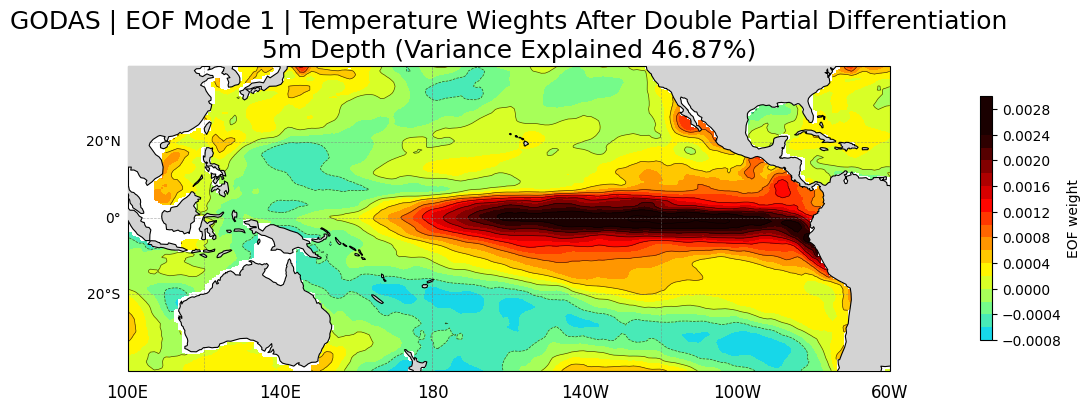

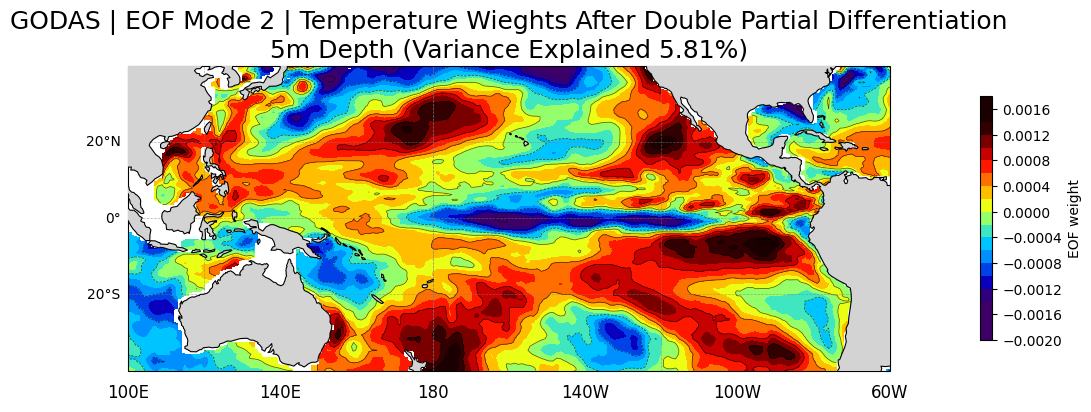

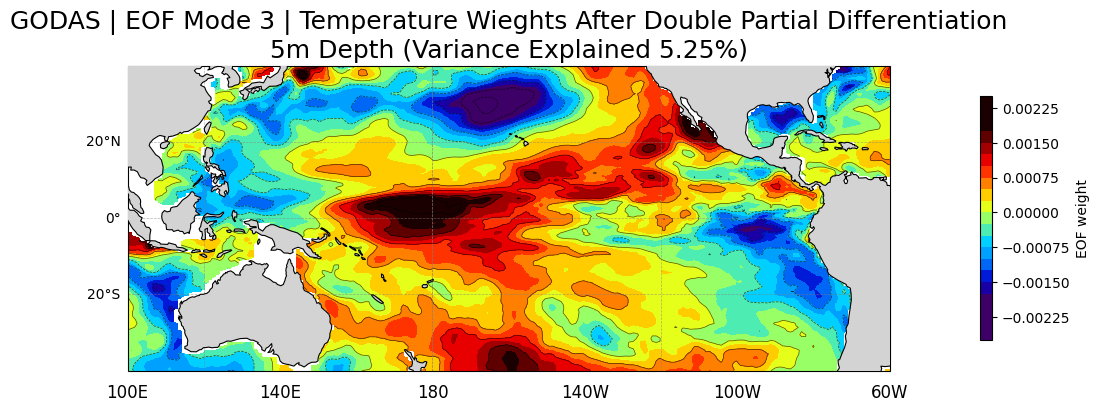

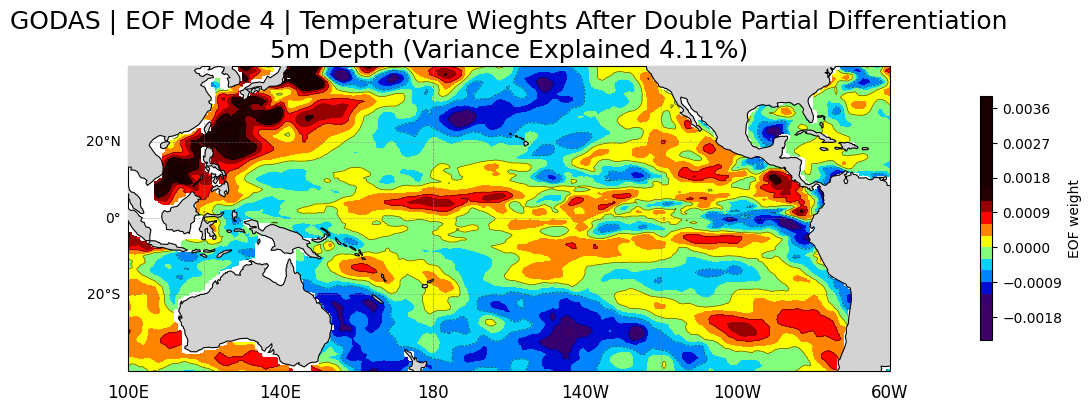

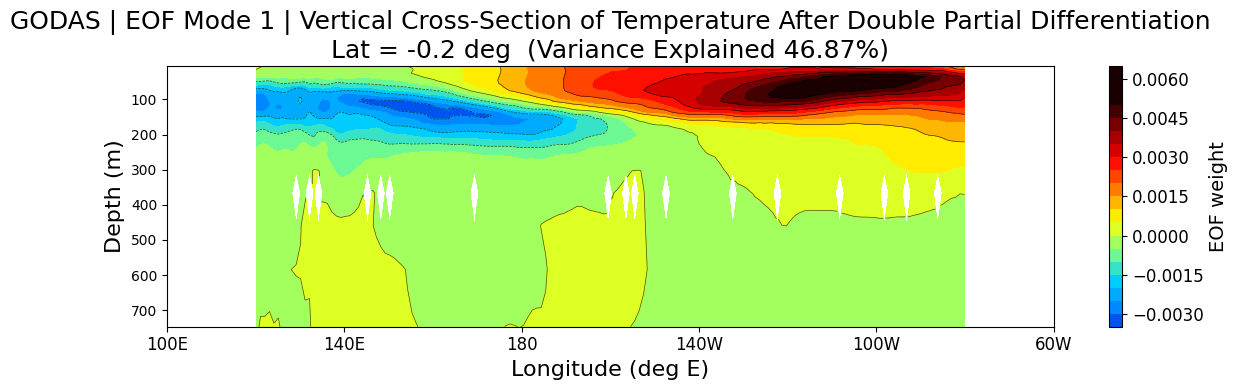

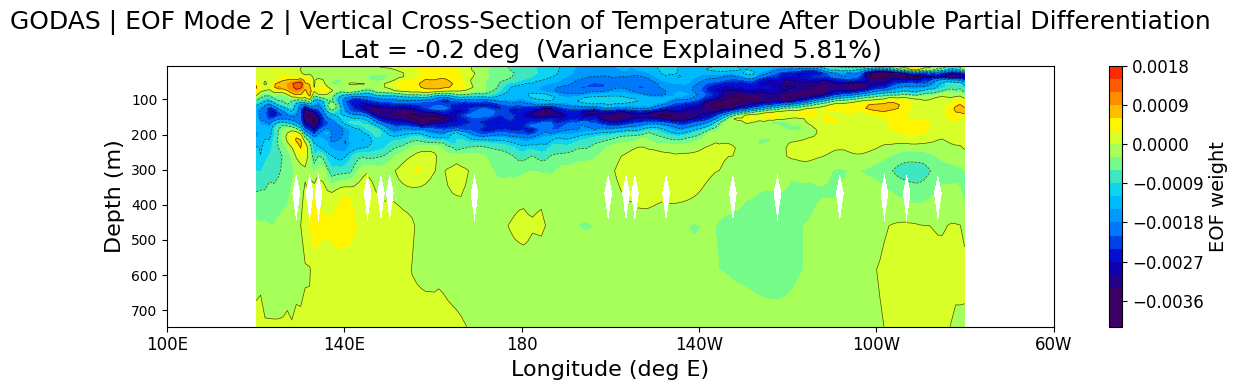

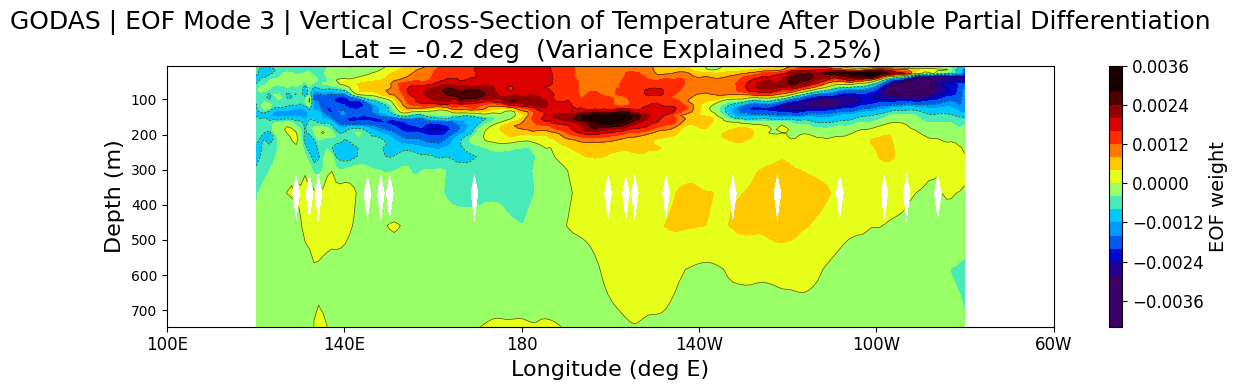

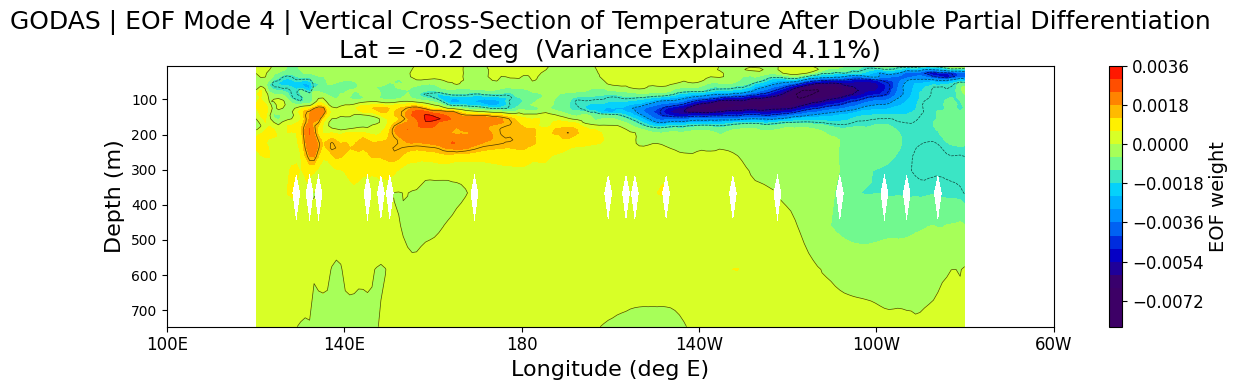

In [1]:
# == Visualization: First 4 EOF Modes =========================================
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fp = r"D:\\OneDrive\\Documents\\M586_Project\\GODAS_Partials_SVD_results_NDJ.nc"

LON_MIN, LON_MAX  = 100, 300
LAT_MIN, LAT_MAX  = -40, 40
N_LON = LON_MAX - LON_MIN                  # 200
N_LAT = (abs(LAT_MAX) + abs(LAT_MIN)) * 3  # grid points in [-40, 40] = 240 Since 0.5 resolution => 80 per 40 degrees => 160 for 80 degrees
N     = 30 * N_LON * N_LAT                 # 1440000
N_LEV = 30


# == Load results =============================================================
ds_svd     = xr.open_dataset(fp)
U_eofs     = ds_svd["U"].values          # (1440000, 38)
sigma      = ds_svd["sigma"].values      # (38,)
valid_mask = ds_svd["valid_mask"].values # (1440000,)

# == Grid coordinates =========================================================
DEPTH_M  = np.array([5, 15, 25, 35, 45, 55, 65, 75, 85, 95, 105, 115, 125,
                     135, 145, 155, 165, 175, 185, 195, 205, 215, 225, 238,
                     262, 303, 366, 459, 584, 747])
LON_VALS = np.linspace(LON_MIN, LON_MAX, N_LON)   # 200 points
LAT_VALS = np.linspace(LAT_MIN, LAT_MAX, N_LAT)   # 240 points

# == Slicing parameters =======================================================
LAT_SLICE = 0.0    # fixed latitude for vertical cross-section (equator)

# == Custom colormap ==========================================================
cmap_colors = [
    "#3d0066",   # near-black deep violet  (coldest)
    "#0000cd",   # medium blue
    "#0080ff",   # bright blue
    "#00cfff",   # cyan
    "#80ff80",   # light green
    "#ffff00",   # yellow
    "#ff8000",   # orange
    "#ff0000",   # red
    "#8b0000",   # dark red
    "#1a0000",   # near-black              (hottest)
]
CMAP = mcolors.LinearSegmentedColormap.from_list("custom_spectral", cmap_colors, N=256)
N_CONTOUR_FILLS = 20
N_CONTOUR_LINES = 10

# == Land fill color ==========================================================
LAND_COLOR = "lightgray"

# == Reshape U to spatial grid ================================================
U_full = np.full((N, 38), np.nan, dtype=np.float32)
U_full[valid_mask, :] = U_eofs[valid_mask, :]
U_grid = U_full.reshape(N_LEV, N_LON, N_LAT, 38)   # (30, 200, 240, 38)

var_exp = sigma**2 / (sigma**2).sum()

# == Latitude index closest to LAT_SLICE ======================================
lat_idx = np.argmin(np.abs(LAT_VALS - LAT_SLICE))
print(f"Vertical cross-section at lat = {LAT_VALS[lat_idx]:.2f} deg  (index {lat_idx})")

# == Plot =====================================================================
PROJ = ccrs.PlateCarree(central_longitude=180)
DATA_CRS = ccrs.PlateCarree()
n_modes = 4

for mode in range(n_modes):

    eof = U_grid[:, :, :, mode]   # (30, 200, 240)

    # -- Horizontal slice: depth level 0  (5 m) -------------------------------
    horiz  = eof[0, :, :]         # (200, 240)  lon x lat
    vlim_h = np.nanpercentile(np.abs(horiz), 98)

    fig, ax = plt.subplots(figsize=(12, 4),
                           subplot_kw={"projection": PROJ})
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=DATA_CRS)

    cf = ax.contourf(LON_VALS, LAT_VALS, horiz.T,
                     levels=N_CONTOUR_FILLS,
                     vmin=-vlim_h, vmax=vlim_h,
                     cmap=CMAP,
                     transform=DATA_CRS)
    ax.contour(LON_VALS, LAT_VALS, horiz.T,
               levels=N_CONTOUR_LINES,
               colors="k", linewidths=0.5, alpha=0.7,
               transform=DATA_CRS)

    # Cartopy overlays
    ax.add_feature(cfeature.LAND, facecolor=LAND_COLOR, zorder=3)
    ax.coastlines(resolution="110m", color="black", linewidth=0.8, zorder=4)

    gl = ax.gridlines(crs=DATA_CRS, draw_labels=True,
                      linewidth=0.5, color="gray",
                      alpha=0.6, linestyle="--")
    gl.top_labels    = False
    gl.right_labels  = False
    gl.bottom_labels = False
    gl.ylocator = mticker.FixedLocator(range(LAT_MIN, LAT_MAX + 1, 20))

    # Manually set xticks to match gridlines
    lon_ticks  = [100, 140, 180, 220, 260, 300]
    lon_labels = ["100E", "140E", "180", "140W", "100W", "60W"]
    for lon, label in zip(lon_ticks, lon_labels):
        ax.text(lon, LAT_MIN - 3.5, label,
                        transform=DATA_CRS,
                        ha="center", va="top",
                        fontsize=12)

    plt.colorbar(cf, ax=ax, label="EOF weight", shrink=0.8, pad=0.08)
    ax.set_xlabel("Longitude (deg E)", fontsize=16)
    ax.set_ylabel("Depth (m)", fontsize=16)
    ax.set_title(f"GODAS | EOF Mode {mode + 1} | Temperature Wieghts After Double Partial Differentiation\n"
                 f"5m Depth (Variance Explained {var_exp[mode]:.2%})", fontsize=18, loc="center")
    plt.tight_layout()
    plt.show()

for mode in range(n_modes):
    
    eof = U_grid[:, :, :, mode]   # (30, 200, 240)

    # -- Vertical cross-section: level vs. lon at equator ---------------------
    vert   = eof[:, :, lat_idx]   # (30, 200)  level x lon
    vlim_v = np.nanpercentile(np.abs(vert), 98)

    fig, ax = plt.subplots(figsize=(12, 4))
    cf = ax.contourf(LON_VALS, DEPTH_M, vert,
                     levels=N_CONTOUR_FILLS,
                     vmin=-vlim_v, vmax=vlim_v,
                     cmap=CMAP)
    ax.contour(LON_VALS, DEPTH_M, vert,
               levels=N_CONTOUR_LINES,
               colors="k", linewidths=0.5, alpha=0.7)

    ax.set_xticks([100, 140, 180, 220, 260, 300])
    ax.set_xticklabels(["100E", "140E", "180", "140W", "100W", "60W"], fontsize=12)
    ax.tick_params(axis="x", labelbottom=True)
    
    cbar = plt.colorbar(cf, ax=ax)
    cbar.ax.tick_params(labelsize=12)
    cbar.set_label("EOF weight", fontsize=14)
    ax.invert_yaxis()
    ax.set_xlabel("Longitude (deg E)", fontsize=16)
    ax.set_ylabel("Depth (m)", fontsize=16)
    ax.set_title(f"GODAS | EOF Mode {mode + 1} | Vertical Cross-Section of Temperature After Double Partial Differentiation\n"
                 f"Lat = {LAT_VALS[lat_idx]:.1f} deg  (Variance Explained {var_exp[mode]:.2%})",
                 fontsize=18, loc="center")
    plt.tight_layout()
    plt.show()

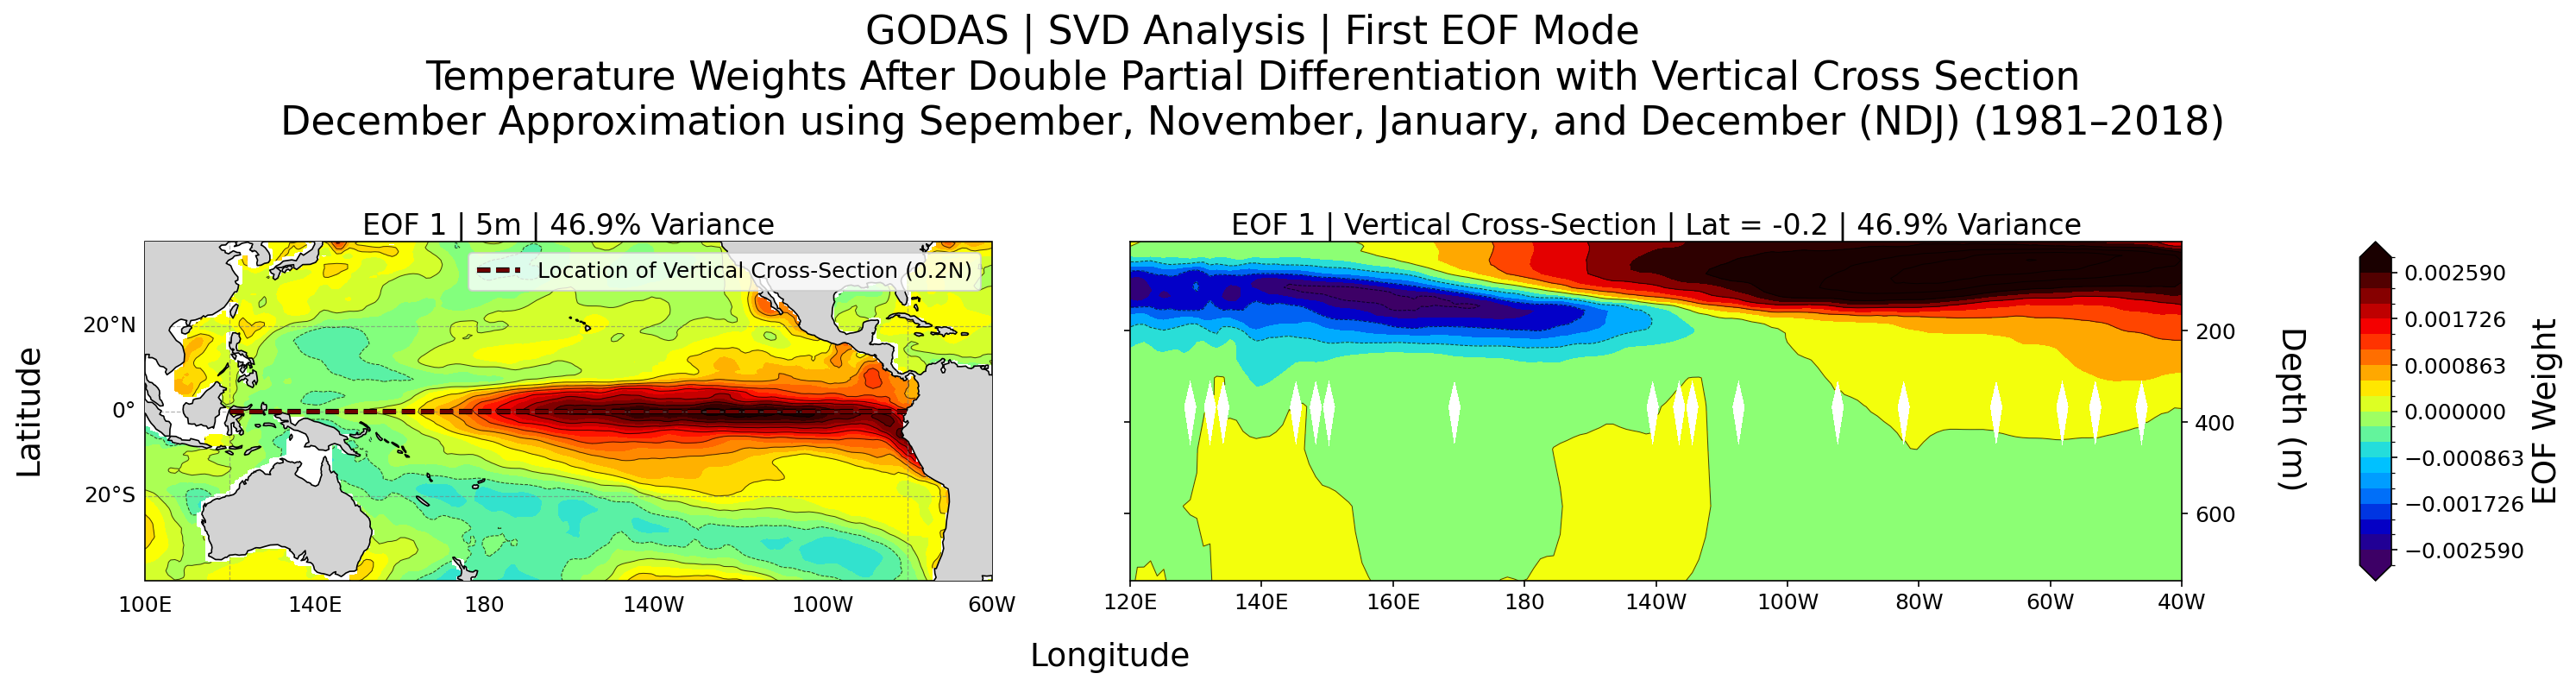

In [ ]:
# == Visualization: First 4 EOF Modes =========================================
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.patheffects as pe

fp = r"D:\\OneDrive\\Documents\\M586_Project\\GODAS_Partials_SVD_results_NDJ.nc"

LON_MIN, LON_MAX  = 100, 300
LAT_MIN, LAT_MAX  = -40, 40
N_LON = LON_MAX - LON_MIN
N_LAT = (abs(LAT_MAX) + abs(LAT_MIN)) * 3
N     = 30 * N_LON * N_LAT
N_LEV = 30

# == Load results =============================================================
ds_svd     = xr.open_dataset(fp)
U_eofs     = ds_svd["U"].values
sigma      = ds_svd["sigma"].values
valid_mask = ds_svd["valid_mask"].values

# == Grid coordinates =========================================================
DEPTH_M  = np.array([5, 15, 25, 35, 45, 55, 65, 75, 85, 95, 105, 115, 125,
                     135, 145, 155, 165, 175, 185, 195, 205, 215, 225, 238,
                     262, 303, 366, 459, 584, 747])
LON_VALS = np.linspace(LON_MIN, LON_MAX, N_LON)
LAT_VALS = np.linspace(LAT_MIN, LAT_MAX, N_LAT)

# == Parameters ===============================================================
LAT_SLICE       = 0.0
N_MODES         = 1
N_CONTOUR_FILLS = 20
N_CONTOUR_LINES = 10
LAND_COLOR      = "lightgray"

# == Custom colormap ==========================================================
cmap_colors = [
    "#3d0066",
    "#0000cd",
    "#0080ff",
    "#00cfff",
    "#80ff80",
    "#ffff00",
    "#ff8000",
    "#ff0000",
    "#8b0000",
    "#1a0000",
]
CMAP   = mcolors.LinearSegmentedColormap.from_list("custom_spectral", cmap_colors, N=256)
bounds = np.linspace(-1, 1, N_CONTOUR_FILLS + 1)   # placeholder, reset after vlim

# == Reshape U to spatial grid ================================================
U_full = np.full((N, 38), np.nan, dtype=np.float32)
U_full[valid_mask, :] = U_eofs[valid_mask, :]
U_grid = U_full.reshape(N_LEV, N_LON, N_LAT, 38)

var_exp = sigma**2 / (sigma**2).sum()
lat_idx = np.argmin(np.abs(LAT_VALS - LAT_SLICE))

# == Global color limits ======================================================
all_vals = []
for mode in range(N_MODES):
    eof = U_grid[:, :, :, mode]
    all_vals.append(eof[0, :, :].ravel())
    all_vals.append(eof[:, :, lat_idx].ravel())
vlim       = np.nanpercentile(np.abs(np.concatenate(all_vals)), 98)
VMIN, VMAX = -vlim, vlim
bounds     = np.linspace(VMIN, VMAX, N_CONTOUR_FILLS + 1)   # defined here
norm       = mcolors.BoundaryNorm(boundaries=bounds, ncolors=CMAP.N, clip=True)

# == Build figure =============================================================
PROJ     = ccrs.PlateCarree(central_longitude=180)
DATA_CRS = ccrs.PlateCarree()

fig = plt.figure(figsize=(22, 3.4 * N_MODES), dpi=150)

gs = gridspec.GridSpec(
    N_MODES, 3,
    figure=fig,
    width_ratios=[1, 1, 0.03],
    hspace=0.25,
    wspace=0.05
)

# Track axes for sharex linking
ax_vert_list = []

for mode in range(N_MODES):

    eof   = U_grid[:, :, :, mode]
    horiz = eof[0, :, :]
    vert  = eof[:, :, lat_idx]
    is_bottom = (mode == N_MODES - 1)

    # -- Left column: horizontal map ------------------------------------------
    ax_map = fig.add_subplot(gs[mode, 0], projection=PROJ)
    ax_map.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=DATA_CRS)

    ax_map.contourf(LON_VALS, LAT_VALS, horiz.T,
                    levels=N_CONTOUR_FILLS,
                    vmin=VMIN, vmax=VMAX,
                    cmap=CMAP,
                    transform=DATA_CRS)
    ax_map.contour(LON_VALS, LAT_VALS, horiz.T,
                   levels=N_CONTOUR_LINES,
                   colors="k", linewidths=0.5, alpha=0.7,
                   transform=DATA_CRS)
    
    # Add a red dashed line for the latitude and width of the vertical cross-section and add label
    line, = ax_map.plot(LON_VALS[20:-20], np.full_like(LON_VALS[20:-20], LAT_VALS[lat_idx]),
                        color="darkred", linestyle="--", linewidth=2, alpha=0.8,
                        transform=DATA_CRS, zorder=5,
                        label=f"Location of Vertical Cross-Section (0.2N)")
    line.set_path_effects([pe.Stroke(linewidth=3, foreground='black'), pe.Normal()])
    ax_map.legend(loc="upper right", fontsize=12, framealpha=0.8)
    
    ax_map.add_feature(cfeature.LAND, facecolor=LAND_COLOR, zorder=3)
    ax_map.coastlines(resolution="110m", color="black", linewidth=0.8, zorder=4)

    gl = ax_map.gridlines(crs=DATA_CRS, draw_labels=False,   # draw_labels=False
                      linewidth=0.6, color="gray",
                      alpha=0.6, linestyle="--",
                      xlocs=[-80, -40, 0, 40, 80, 120],
                      ylocs=list(range(LAT_MIN, LAT_MAX + 1, 20)))
 
    if not is_bottom:
        gl.bottom_labels = False
    gl.top_labels   = False
    gl.right_labels = False
    gl.left_labels  = True
    gl.ylabel_style = {"size": 12}

    if is_bottom:
        lon_ticks  = [100, 140, 180, 220, 260, 300]
        lon_labels = ["100E", "140E", "180", "140W", "100W", "60W"]
        for lon, label in zip(lon_ticks, lon_labels):
            ax_map.text(lon, LAT_MIN - 3.5, label,
                        transform=DATA_CRS,
                        ha="center", va="top",
                        fontsize=12)

    ax_map.set_title(f"EOF {mode + 1} | 5m | {var_exp[mode]:.1%} Variance",
                     fontsize=16, pad=3)

    # -- Right column: vertical cross-section ---------------------------------
    sharex_ax = ax_vert_list[0] if ax_vert_list else None
    ax_vert = fig.add_subplot(gs[mode, 1], sharex=sharex_ax)
    ax_vert_list.append(ax_vert)

    ax_vert.contourf(LON_VALS[20:-20], DEPTH_M , vert[:, 20:-20],
                     levels=N_CONTOUR_FILLS,
                     vmin=VMIN, vmax=VMAX,
                     cmap=CMAP)
    ax_vert.contour(LON_VALS[20:-20], DEPTH_M, vert[:, 20:-20],
                    levels=N_CONTOUR_LINES,
                    colors="k", linewidths=0.5, alpha=0.7)
    ax_vert.invert_yaxis()

    ax_vert.yaxis.set_ticks_position("both")
    ax_vert.yaxis.set_label_position("right")
    ax_vert.tick_params(axis="y", labelright=True, labelleft=False, labelsize=12)

    if is_bottom:
        ax_vert.set_xticks([120, 140, 160, 180, 200, 220, 240, 260, 280])
        ax_vert.set_xticklabels(["120E", "140E", "160E", "180", "140W", "100W", "80W", "60W", "40W"], fontsize=12)
    else:
        ax_vert.set_xticks([100, 140, 180, 220, 260, 300])
        ax_vert.tick_params(axis="x", labelbottom=False)

    ax_vert.set_title(f"EOF {mode + 1} | Vertical Cross-Section | Lat = {LAT_VALS[lat_idx]:.1f} | "
                      f"{var_exp[mode]:.1%} Variance",
                      fontsize=16, pad=3)

# == Vertical colorbar ========================================================
cbar_ax = fig.add_subplot(gs[:, 2])
bounds = np.linspace(VMIN, VMAX, N_CONTOUR_FILLS + 1)
norm   = mcolors.BoundaryNorm(boundaries=bounds, ncolors=CMAP.N, clip=True)
sm     = plt.cm.ScalarMappable(cmap=CMAP, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="vertical", extend="both", pad=0.5)
cbar.set_label("EOF Weight", fontsize=18)
pos = cbar_ax.get_position()
cbar.ax.tick_params(labelsize=12)
cbar_ax.set_position([pos.x0 + 0.05, pos.y0, pos.width, pos.height])
fig.suptitle("GODAS | SVD Analysis | First EOF Mode\nTemperature Weights After Double Partial Differentiation with Vertical Cross Section\nDecember Approximation using Sepember, November, January, and December (NDJ) (1981–2018)",
             fontsize=22,x =0.55, y=1.4)
fig.text(0.5, -0.1, "Longitude", ha="center", va="bottom", fontsize=18)
fig.text(0.92, 0.5, "Depth (m)", ha="right", va="center", fontsize=18, rotation=270)
fig.text(0.12, 0.5, "Latitude", ha="center", va="center", fontsize=18, rotation=90)
plt.show()

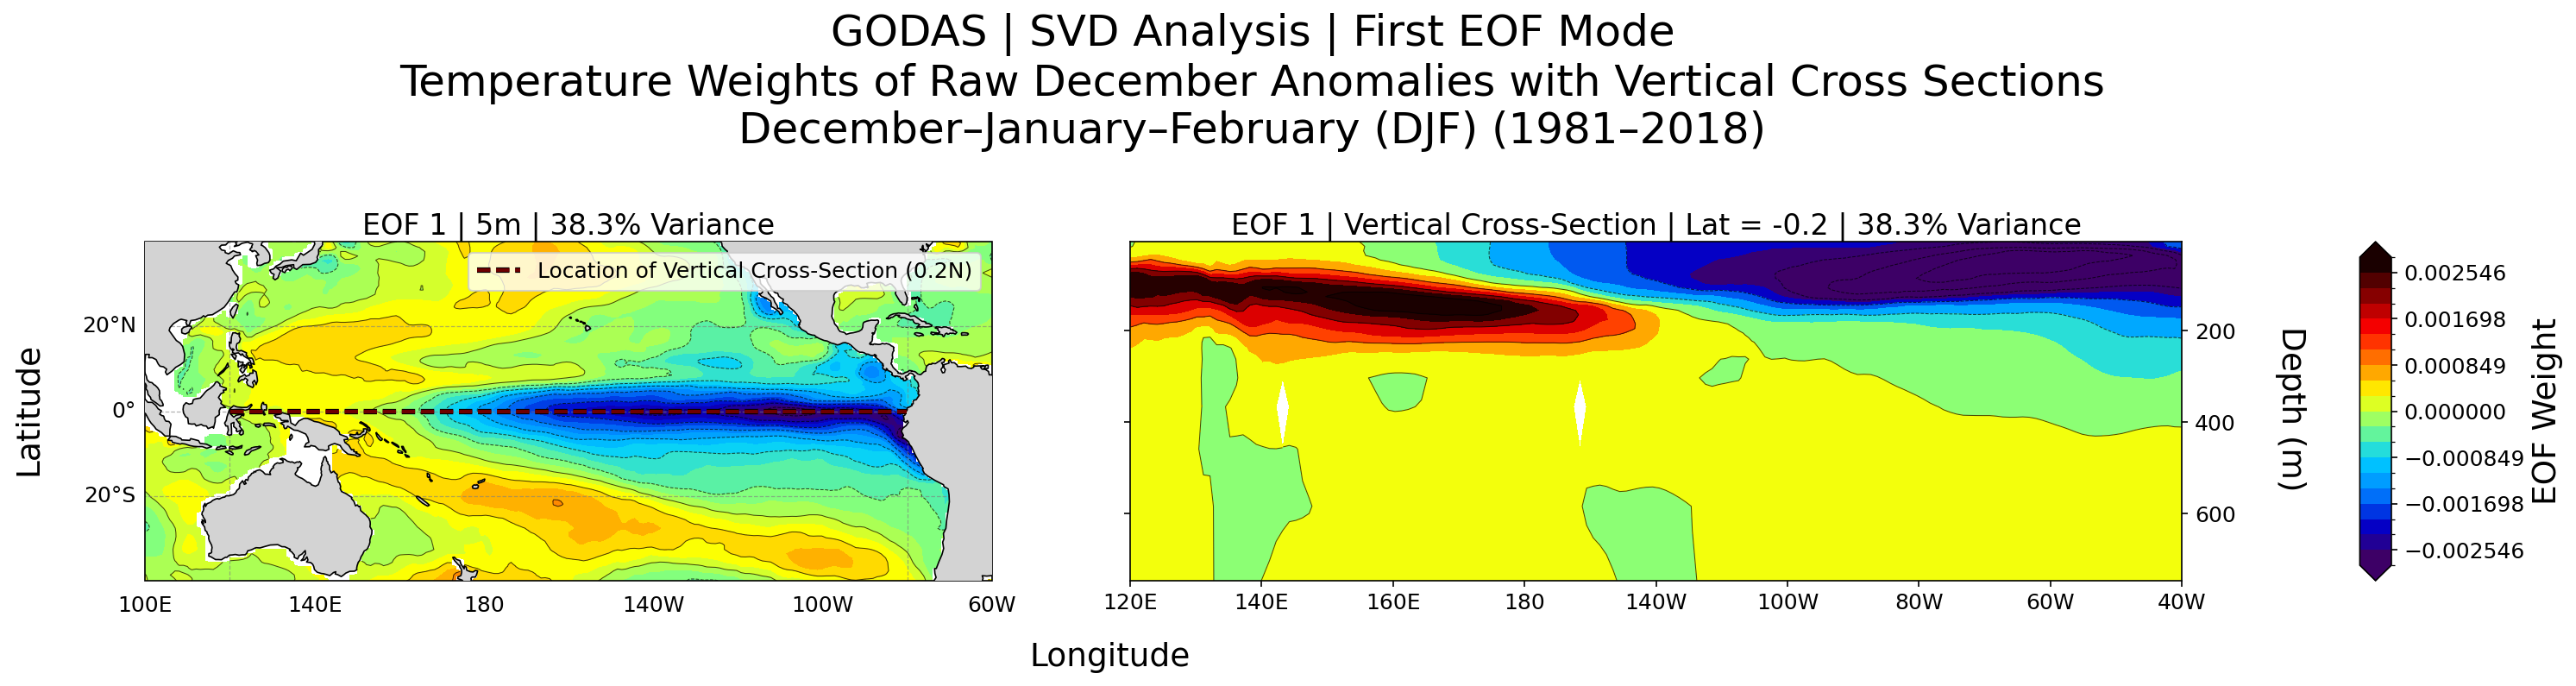

In [172]:
# == Visualization: First 4 EOF Modes =========================================
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.patheffects as pe

fp = r"D:\\OneDrive\\Documents\\M586_Project\\GODAS_Raw_SVD_results_NDJ.nc"

LON_MIN, LON_MAX  = 100, 300
LAT_MIN, LAT_MAX  = -40, 40
N_LON = LON_MAX - LON_MIN
N_LAT = (abs(LAT_MAX) + abs(LAT_MIN)) * 3
N     = 30 * N_LON * N_LAT
N_LEV = 30

# == Load results =============================================================
ds_svd     = xr.open_dataset(fp)
U_eofs     = ds_svd["U"].values
sigma      = ds_svd["sigma"].values
valid_mask = ds_svd["valid_mask"].values

# == Grid coordinates =========================================================
DEPTH_M  = np.array([5, 15, 25, 35, 45, 55, 65, 75, 85, 95, 105, 115, 125,
                     135, 145, 155, 165, 175, 185, 195, 205, 215, 225, 238,
                     262, 303, 366, 459, 584, 747])
LON_VALS = np.linspace(LON_MIN, LON_MAX, N_LON)
LAT_VALS = np.linspace(LAT_MIN, LAT_MAX, N_LAT)

# == Parameters ===============================================================
LAT_SLICE       = 0.0
N_MODES         = 1
N_CONTOUR_FILLS = 20
N_CONTOUR_LINES = 10
LAND_COLOR      = "lightgray"

# == Custom colormap ==========================================================
cmap_colors = [
    "#3d0066",
    "#0000cd",
    "#0080ff",
    "#00cfff",
    "#80ff80",
    "#ffff00",
    "#ff8000",
    "#ff0000",
    "#8b0000",
    "#1a0000",
]
CMAP   = mcolors.LinearSegmentedColormap.from_list("custom_spectral", cmap_colors, N=256)
bounds = np.linspace(-1, 1, N_CONTOUR_FILLS + 1)   # placeholder, reset after vlim

# == Reshape U to spatial grid ================================================
U_full = np.full((N, 38), np.nan, dtype=np.float32)
U_full[valid_mask, :] = U_eofs[valid_mask, :]
U_grid = U_full.reshape(N_LEV, N_LON, N_LAT, 38)

var_exp = sigma**2 / (sigma**2).sum()
lat_idx = np.argmin(np.abs(LAT_VALS - LAT_SLICE))

# == Global color limits ======================================================
all_vals = []
for mode in range(N_MODES):
    eof = U_grid[:, :, :, mode]
    all_vals.append(eof[0, :, :].ravel())
    all_vals.append(eof[:, :, lat_idx].ravel())
vlim       = np.nanpercentile(np.abs(np.concatenate(all_vals)), 98)
VMIN, VMAX = -vlim, vlim
bounds     = np.linspace(VMIN, VMAX, N_CONTOUR_FILLS + 1)   # defined here
norm       = mcolors.BoundaryNorm(boundaries=bounds, ncolors=CMAP.N, clip=True)

# == Build figure =============================================================
PROJ     = ccrs.PlateCarree(central_longitude=180)
DATA_CRS = ccrs.PlateCarree()

fig = plt.figure(figsize=(22, 3.4 * N_MODES), dpi=150)

gs = gridspec.GridSpec(
    N_MODES, 3,
    figure=fig,
    width_ratios=[1, 1, 0.03],
    hspace=0.25,
    wspace=0.05
)

# Track axes for sharex linking
ax_vert_list = []

for mode in range(N_MODES):

    eof   = U_grid[:, :, :, mode]
    horiz = eof[0, :, :]
    vert  = eof[:, :, lat_idx]
    is_bottom = (mode == N_MODES - 1)

    # -- Left column: horizontal map ------------------------------------------
    ax_map = fig.add_subplot(gs[mode, 0], projection=PROJ)
    ax_map.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=DATA_CRS)

    ax_map.contourf(LON_VALS, LAT_VALS, horiz.T,
                    levels=N_CONTOUR_FILLS,
                    vmin=VMIN, vmax=VMAX,
                    cmap=CMAP,
                    transform=DATA_CRS)
    ax_map.contour(LON_VALS, LAT_VALS, horiz.T,
                   levels=N_CONTOUR_LINES,
                   colors="k", linewidths=0.5, alpha=0.7,
                   transform=DATA_CRS)
    
    # Add a red dashed line for the latitude and width of the vertical cross-section and add label
    line, = ax_map.plot(LON_VALS[20:-20], np.full_like(LON_VALS[20:-20], LAT_VALS[lat_idx]),
                        color="darkred", linestyle="--", linewidth=2, alpha=0.8,
                        transform=DATA_CRS, zorder=5,
                        label=f"Location of Vertical Cross-Section (0.2N)")
    line.set_path_effects([pe.Stroke(linewidth=3, foreground='black'), pe.Normal()])
    ax_map.legend(loc="upper right", fontsize=12, framealpha=0.8)
    
    ax_map.add_feature(cfeature.LAND, facecolor=LAND_COLOR, zorder=3)
    ax_map.coastlines(resolution="110m", color="black", linewidth=0.8, zorder=4)

    gl = ax_map.gridlines(crs=DATA_CRS, draw_labels=False,   # draw_labels=False
                      linewidth=0.6, color="gray",
                      alpha=0.6, linestyle="--",
                      xlocs=[-80, -40, 0, 40, 80, 120],
                      ylocs=list(range(LAT_MIN, LAT_MAX + 1, 20)))
 
    if not is_bottom:
        gl.bottom_labels = False
    gl.top_labels   = False
    gl.right_labels = False
    gl.left_labels  = True
    gl.ylabel_style = {"size": 12}

    if is_bottom:
        lon_ticks  = [100, 140, 180, 220, 260, 300]
        lon_labels = ["100E", "140E", "180", "140W", "100W", "60W"]
        for lon, label in zip(lon_ticks, lon_labels):
            ax_map.text(lon, LAT_MIN - 3.5, label,
                        transform=DATA_CRS,
                        ha="center", va="top",
                        fontsize=12)

    ax_map.set_title(f"EOF {mode + 1} | 5m | {var_exp[mode]:.1%} Variance",
                     fontsize=16, pad=3)

    # -- Right column: vertical cross-section ---------------------------------
    sharex_ax = ax_vert_list[0] if ax_vert_list else None
    ax_vert = fig.add_subplot(gs[mode, 1], sharex=sharex_ax)
    ax_vert_list.append(ax_vert)

    ax_vert.contourf(LON_VALS[20:-20], DEPTH_M , vert[:, 20:-20],
                     levels=N_CONTOUR_FILLS,
                     vmin=VMIN, vmax=VMAX,
                     cmap=CMAP)
    ax_vert.contour(LON_VALS[20:-20], DEPTH_M, vert[:, 20:-20],
                    levels=N_CONTOUR_LINES,
                    colors="k", linewidths=0.5, alpha=0.7)
    ax_vert.invert_yaxis()

    ax_vert.yaxis.set_ticks_position("both")
    ax_vert.yaxis.set_label_position("right")
    ax_vert.tick_params(axis="y", labelright=True, labelleft=False, labelsize=12)

    if is_bottom:
        ax_vert.set_xticks([120, 140, 160, 180, 200, 220, 240, 260, 280])
        ax_vert.set_xticklabels(["120E", "140E", "160E", "180", "140W", "100W", "80W", "60W", "40W"], fontsize=12)
    else:
        ax_vert.set_xticks([100, 140, 180, 220, 260, 300])
        ax_vert.tick_params(axis="x", labelbottom=False)

    ax_vert.set_title(f"EOF {mode + 1} | Vertical Cross-Section | Lat = {LAT_VALS[lat_idx]:.1f} | "
                      f"{var_exp[mode]:.1%} Variance",
                      fontsize=16, pad=3)

# == Vertical colorbar ========================================================
cbar_ax = fig.add_subplot(gs[:, 2])
bounds = np.linspace(VMIN, VMAX, N_CONTOUR_FILLS + 1)
norm   = mcolors.BoundaryNorm(boundaries=bounds, ncolors=CMAP.N, clip=True)
sm     = plt.cm.ScalarMappable(cmap=CMAP, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="vertical", extend="both", pad=0.5)
cbar.set_label("EOF Weight", fontsize=18)
pos = cbar_ax.get_position()
cbar.ax.tick_params(labelsize=12)
cbar_ax.set_position([pos.x0 + 0.05, pos.y0, pos.width, pos.height])
fig.suptitle("GODAS | SVD Analysis | First EOF Mode\nTemperature Weights of Raw December Anomalies with Vertical Cross Sections\nDecember–January–February (DJF) (1981–2018)",
             fontsize=24, x= 0.55, y=1.4)
fig.text(0.5, -0.1, "Longitude", ha="center", va="bottom", fontsize=18)
fig.text(0.92, 0.5, "Depth (m)", ha="right", va="center", fontsize=18, rotation=270)
fig.text(0.12, 0.5, "Latitude", ha="center", va="center", fontsize=18, rotation=90)
plt.show()

C:\Users\Matt\AppData\Roaming\Python\Python311\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'cfgrib' loading failed:
module 'cfgrib.messages' has no attribute 'DEFAULT_INDEXPATH'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


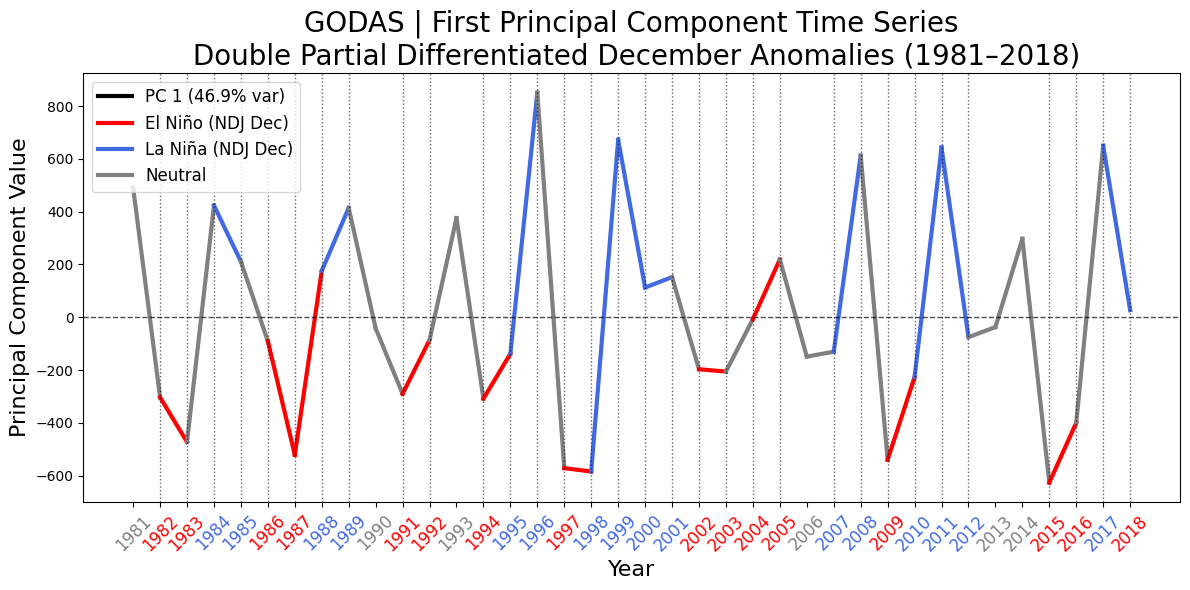

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import xarray as xr

fp = r"D:\\OneDrive\\Documents\\M586_Project\\GODAS_Partials_SVD_results_NDJ.nc"
ds_svd = xr.open_dataset(fp, engine="netcdf4")
V = ds_svd["V"].values
sigma = ds_svd["sigma"].values

modes_to_plot = 1
years = np.arange(1981, 2019)

el_nino_years = np.array([1982, 1986, 1987, 1991, 1994, 1997, 2002, 2004, 2009, 2015, 2018])
la_nina_years = np.array([1984, 1988, 1995, 1998, 1999, 2000, 2007, 2010, 2011, 2017])

nino_mask = np.isin(years, el_nino_years)
nina_mask = np.isin(years, la_nina_years)

def enso_state(i):
    if nino_mask[i]: return "nino"
    if nina_mask[i]: return "nina"
    return "neutral"

linestyles = ["-",  "--",  ":"]
linewidths = [3,     2.5,   2]

fig, ax = plt.subplots(figsize=(12, 6))

for mode in range(modes_to_plot):
    for i in range(len(years) - 1):
        # Color determined by LEFT endpoint only — segment starts in this state
        col = "red" if nino_mask[i] else ("royalblue" if nina_mask[i] else "gray")
        ax.plot(years[i:i + 2], sigma[mode]*V[i:i + 2, mode],
                color=col, linewidth=linewidths[mode], linestyle=linestyles[mode])
        
# A line at the start AND end of every individual ENSO year
enso_boundaries = set()
for yr in np.concatenate([el_nino_years, la_nina_years]):
    enso_boundaries.add(yr)        # left edge of ENSO year
    enso_boundaries.add(yr + 1)    # right edge of ENSO year

for yr in sorted(enso_boundaries):
    if years[0] <= yr <= years[-1]:
        ax.axvline(yr, color="k", linestyle=":", alpha=0.6, linewidth=1)


# Legend
for mode in range(modes_to_plot):
    ax.plot([], [], color="black", linewidth=linewidths[mode], linestyle=linestyles[mode],
            label=f"PC {mode + 1} ({sigma[mode]**2 / (sigma**2).sum():.1%} var)")
ax.plot([], [], color="red",       linewidth=3, label="El Niño (NDJ Dec)")
ax.plot([], [], color="royalblue", linewidth=3, label="La Niña (NDJ Dec)")
ax.plot([], [], color="gray",      linewidth=3, label="Neutral")

# Add horizontal gridlines at y=0
ax.axhline(0, color="black", linestyle="--", alpha=0.7, linewidth=1)

ax.set_xlabel("Year", fontsize=16)
ax.set_ylabel("Principal Component Value", fontsize=16)
plt.title("GODAS | First Principal Component Time Series\n Double Partial Differentiated December Anomalies (1981–2018)", fontsize=20)
ax.legend(fontsize=12)

el_nino_set = set(el_nino_years)
la_nina_set = set(la_nina_years)

ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, fontsize=12)

for tick, yr in zip(ax.get_xticklabels(), years):
    if yr in el_nino_set:
        tick.set_color("red")
    elif yr in la_nina_set:
        tick.set_color("royalblue")
    elif yr - 1 in el_nino_set:        # end boundary of an El Niño period
        tick.set_color("red")
    elif yr - 1 in la_nina_set:        # end boundary of a La Niña period
        tick.set_color("royalblue")
    else:
        tick.set_color("gray")

ax.tick_params(axis="x", which="minor", length=4)
plt.tight_layout()
plt.show()


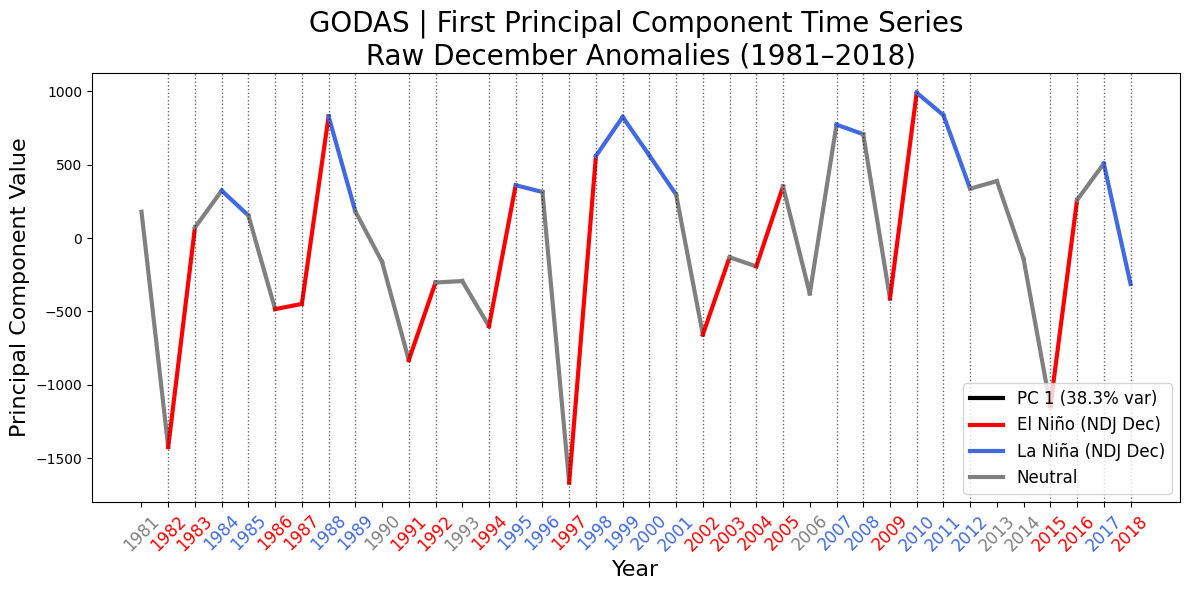

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import xarray as xr

fp = r"D:\\OneDrive\\Documents\\M586_Project\\GODAS_Raw_SVD_results_NDJ.nc"
ds_svd = xr.open_dataset(fp, engine="netcdf4")
V = ds_svd["V"].values
sigma = ds_svd["sigma"].values

modes_to_plot = 1
years = np.arange(1981, 2019)

el_nino_years = np.array([1982, 1986, 1987, 1991, 1994, 1997, 2002, 2004, 2009, 2015, 2018])
la_nina_years = np.array([1984, 1988, 1995, 1998, 1999, 2000, 2007, 2010, 2011, 2017])

nino_mask = np.isin(years, el_nino_years)
nina_mask = np.isin(years, la_nina_years)

def enso_state(i):
    if nino_mask[i]: return "nino"
    if nina_mask[i]: return "nina"
    return "neutral"

linestyles = ["-",  "--",  ":"]
linewidths = [3,     2.5,   2]

fig, ax = plt.subplots(figsize=(12, 6))

for mode in range(modes_to_plot):
    for i in range(len(years) - 1):
        # Color determined by LEFT endpoint only — segment starts in this state
        col = "red" if nino_mask[i] else ("royalblue" if nina_mask[i] else "gray")
        ax.plot(years[i:i + 2], sigma[mode]*V[i:i + 2, mode],
                color=col, linewidth=linewidths[mode], linestyle=linestyles[mode])
        
# A line at the start AND end of every individual ENSO year
enso_boundaries = set()
for yr in np.concatenate([el_nino_years, la_nina_years]):
    enso_boundaries.add(yr)        # left edge of ENSO year
    enso_boundaries.add(yr + 1)    # right edge of ENSO year

for yr in sorted(enso_boundaries):
    if years[0] <= yr <= years[-1]:
        ax.axvline(yr, color="k", linestyle=":", alpha=0.6, linewidth=1)


# Legend
for mode in range(modes_to_plot):
    ax.plot([], [], color="black", linewidth=linewidths[mode], linestyle=linestyles[mode],
            label=f"PC {mode + 1} ({sigma[mode]**2 / (sigma**2).sum():.1%} var)")
ax.plot([], [], color="red",       linewidth=3, label="El Niño (NDJ Dec)")
ax.plot([], [], color="royalblue", linewidth=3, label="La Niña (NDJ Dec)")
ax.plot([], [], color="gray",      linewidth=3, label="Neutral")

ax.set_xlabel("Year", fontsize=16)
ax.set_ylabel("Principal Component Value", fontsize=16)
ax.set_title("GODAS | First Principal Component Time Series\n Raw December Anomalies (1981–2018)", fontsize=20)
ax.legend(fontsize=12)

el_nino_set = set(el_nino_years)
la_nina_set = set(la_nina_years)

ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, fontsize=12)

for tick, yr in zip(ax.get_xticklabels(), years):
    if yr in el_nino_set:
        tick.set_color("red")
    elif yr in la_nina_set:
        tick.set_color("royalblue")
    elif yr - 1 in el_nino_set:        # end boundary of an El Niño period
        tick.set_color("red")
    elif yr - 1 in la_nina_set:        # end boundary of a La Niña period
        tick.set_color("royalblue")
    else:
        tick.set_color("gray")


ax.tick_params(axis="x", which="minor", length=4)
plt.tight_layout()
plt.show()


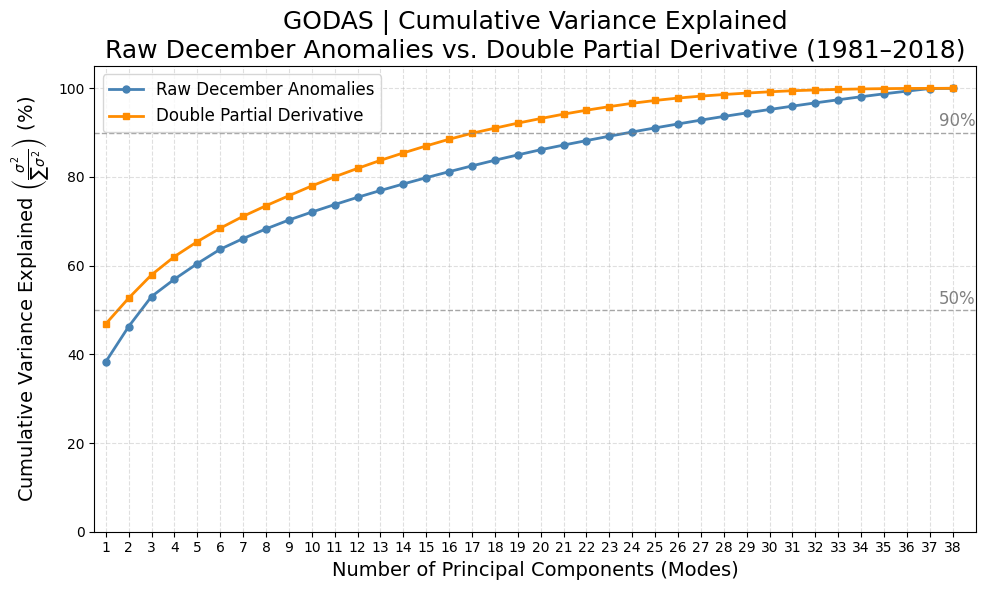

In [63]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

fp_raw = r"D:\OneDrive\Documents\M586_Project\GODAS_Raw_SVD_results_NDJ.nc"
fp_par = r"D:\OneDrive\Documents\M586_Project\GODAS_Partials_SVD_results_NDJ.nc"

ds_raw = xr.open_dataset(fp_raw, engine="netcdf4")
ds_par = xr.open_dataset(fp_par, engine="netcdf4")

sigma_raw = ds_raw["sigma"].values
sigma_par = ds_par["sigma"].values

cvar_raw = np.cumsum(sigma_raw**2) / (sigma_raw**2).sum() * 100
cvar_par = np.cumsum(sigma_par**2) / (sigma_par**2).sum() * 100

n_modes = np.arange(1, len(sigma_raw) + 1)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(n_modes, cvar_raw, color="steelblue",  linestyle="-", linewidth=2,
        marker="o", markersize=5, label="Raw December Anomalies")
ax.plot(n_modes, cvar_par, color="darkorange", linestyle="-", linewidth=2,
        marker="s", markersize=5, label="Double Partial Derivative")

for threshold in [50, 90]:
    ax.axhline(threshold, color="grey", linestyle="--", linewidth=1, alpha=0.7)
    ax.text(n_modes[-1] - 0.6, threshold + 0.5, f"{threshold}%", fontsize=12,
            color="grey", va="bottom")

ax.set_xlabel("Number of Principal Components (Modes)", fontsize=14)
ax.set_ylabel(r"Cumulative Variance Explained $\left(\frac{\sigma^2}{\sum \sigma^2}\right)$ (%)", fontsize=14)
ax.set_title(
    r"GODAS | Cumulative Variance Explained" + "\n" +
    r"Raw December Anomalies vs. Double Partial Derivative (1981–2018)", fontsize=18)
ax.set_xticks(n_modes)
ax.set_xlim(0.5, len(n_modes) + 1)
ax.set_ylim(0, 105)
ax.legend(fontsize=12)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


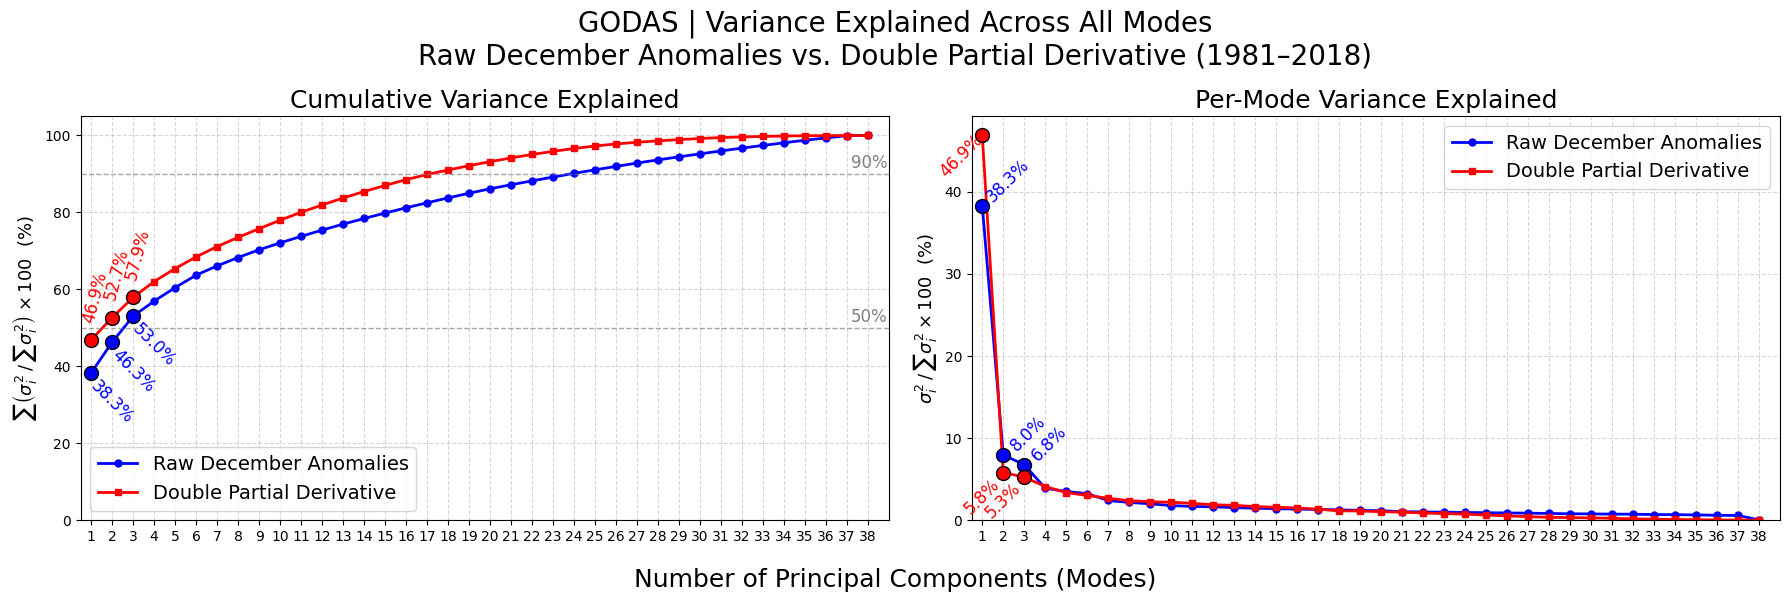

In [150]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

fp_raw = r"D:\OneDrive\Documents\M586_Project\GODAS_Raw_SVD_results_NDJ.nc"
fp_par = r"D:\OneDrive\Documents\M586_Project\GODAS_Partials_SVD_results_NDJ.nc"

ds_raw = xr.open_dataset(fp_raw, engine="netcdf4")
ds_par = xr.open_dataset(fp_par, engine="netcdf4")

sigma_raw = ds_raw["sigma"].values
sigma_par = ds_par["sigma"].values

var_raw  = sigma_raw**2 / (sigma_raw**2).sum() * 100
var_par  = sigma_par**2 / (sigma_par**2).sum() * 100
cvar_raw = np.cumsum(var_raw)
cvar_par = np.cumsum(var_par)

n_modes = np.arange(1, len(sigma_raw) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharex=True)

# ── Left: Cumulative Variance ─────────────────────────────────────────────────
ax1.plot(n_modes, cvar_raw, color="blue",  linestyle="-", linewidth=2,
         marker="o", markersize=5, label="Raw December Anomalies")
ax1.plot(n_modes, cvar_par, color="red", linestyle="-", linewidth=2,
         marker="s", markersize=5, label="Double Partial Derivative")

for threshold in [50, 90]:
    ax1.axhline(threshold, color="grey", linestyle="--", linewidth=1, alpha=0.7)
    ax1.text(n_modes[-1] - 0.8, threshold + 0.5, f"{threshold}%", fontsize=12,
             color="grey", va="bottom")

ax1.set_ylabel(
    r"$\sum \left( \sigma_i^2 \slash \sum \sigma_i^2 \right) \times 100$  (%)",
    fontsize=13)
ax1.set_title("Cumulative Variance Explained", fontsize=18)
ax1.set_xticks(n_modes)
ax1.set_xlim(0.5, len(n_modes) + 1)
ax1.set_ylim(0, 105)
ax1.legend(fontsize=14)
ax1.grid(True, linestyle="--", alpha=0.5)

# ── Right: Per-Mode Variance Explained ───────────────────────────────────────
ax2.plot(n_modes, var_raw, color="blue",  linestyle="-", linewidth=2,
         marker="o", markersize=5, label="Raw December Anomalies")
ax2.plot(n_modes, var_par, color="red", linestyle="-", linewidth=2,
         marker="s", markersize=5, label="Double Partial Derivative")

ax2.set_ylabel(
    r"$\sigma_i^2 \slash \sum \sigma_i^2 \times 100$  (%)",
    fontsize=13)
ax2.set_title("Per-Mode Variance Explained", fontsize=18)
ax2.set_xticks(n_modes)
ax2.set_xlim(0.5, len(n_modes) + 1)
ax2.set_ylim(0)
ax2.legend(fontsize=14)
ax2.grid(True, linestyle="--", alpha=0.5)

fig.supxlabel("Number of Principal Components (Modes)", fontsize=18, y=0.01)
fig.suptitle(
    "GODAS | Variance Explained Across All Modes\n"
    "Raw December Anomalies vs. Double Partial Derivative (1981–2018)",
    fontsize=20)
# Add text to show the values of the first 3 modes on the cumulative variance plot
for i in range(3):
    ax1.text(n_modes[i] + 1, cvar_raw[i] - 13, f"{cvar_raw[i]:.1f}%", fontsize=12, rotation=-45,
             color="blue", ha="center")
    ax1.text(n_modes[i] + 0.2 , cvar_par[i] + 5, f"{cvar_par[i]:.1f}%", fontsize=12, rotation= 75,
             color="red", ha="center")
    ax2.text(n_modes[i] + 1.2, var_raw[i] + 0.5 , f"{var_raw[i]:.1f}%", fontsize=12, rotation= 45,
             color="blue", ha="center")
    ax2.text(n_modes[i] - 1, var_par[i] - 5, f"{var_par[i]:.1f}%", fontsize=12, rotation= 45,
             color="red", ha="center")
    # Also add a larger scatter point for the first 3 modes
    ax1.scatter(n_modes[i], cvar_raw[i], color="blue", s=100, edgecolor="k", zorder=5)
    ax1.scatter(n_modes[i], cvar_par[i], color="red", s=100, edgecolor="k", zorder=5)
    ax2.scatter(n_modes[i], var_raw[i], color="blue", s=100, edgecolor="k", zorder=5)
    ax2.scatter(n_modes[i], var_par[i], color="red", s=100, edgecolor="k", zorder=5)
plt.tight_layout()
plt.show()
